<a href="https://colab.research.google.com/github/2katsu22/xwoba_speed_model/blob/main/xwoba_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, log_loss
from sklearn.model_selection import cross_val_score, GridSearchCV
from google.colab import drive
import pickle
import seaborn as sns
colour_palette = ['#FFB000','#648FFF','#785EF0',
                  '#DC267F','#FE6100','#3D1EB2',
                  '#894D80','#16AA02','#B5592B',
                  '#A3C1ED']

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the file paths in your Google Drive
file_paths = [
    '/content/drive/My Drive/mlb_data_by_gamepk_2021.pkl',
    '/content/drive/My Drive/mlb_data_by_gamepk_2022.pkl',
    '/content/drive/My Drive/mlb_data_by_gamepk_2023.pkl',
    '/content/drive/My Drive/mlb_data_by_gamepk_2024.pkl'
]

# Load the data from the pickle files into a list of dictionaries
mlb_data = []
for file_path in file_paths:
    try:
        with open(file_path, 'rb') as file:
            data = pickle.load(file)
            mlb_data.append(data)
            print(f"Data loaded successfully from {file_path}")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while loading {file_path}: {e}")

# Now you have a list named 'mlb_data' where each element is a dictionary
# loaded from one of the pickle files. You can access them like this:
# mlb_data[0]  # Access the data from the first file (2021)
# mlb_data[1]  # Access the data from the second file (2022)
# and so on...


Mounted at /content/drive
Data loaded successfully from /content/drive/My Drive/mlb_data_by_gamepk_2021.pkl
Data loaded successfully from /content/drive/My Drive/mlb_data_by_gamepk_2022.pkl
Data loaded successfully from /content/drive/My Drive/mlb_data_by_gamepk_2023.pkl
Data loaded successfully from /content/drive/My Drive/mlb_data_by_gamepk_2024.pkl


PITCH LEVEL DATA:

In [ ]:
import pandas as pd
import json
from tqdm import tqdm
import numpy as np

def extract_pitch_data(mlb_data_by_gamepk):
    """
    Extract pitch level data from MLB Stats API data where data is keyed by gamePk

    Parameters:
    mlb_data_by_gamepk: Dictionary with gamePk as keys and game data as values

    Returns:
    DataFrame with pitch-level data
    """
    all_pitches = []

    # Loop through each game using the gamePk keys
    for game_pk, game_data in tqdm(mlb_data_by_gamepk.items(), desc="Processing games"):
        try:
            # Navigate to the allPlays array
            all_plays = game_data.get('liveData', {}).get('plays', {}).get('allPlays', [])

            # Loop through each play
            for play_idx, play in enumerate(all_plays):
                ab_index = play.get('about', {}).get('atBatIndex')
                inning = play.get('about', {}).get('inning')
                half_inning = play.get('about', {}).get('halfInning')

                # Get batter and pitcher info
                batter_id = play.get('matchup', {}).get('batter', {}).get('id')
                batter_name = play.get('matchup', {}).get('batter', {}).get('fullName')
                pitcher_id = play.get('matchup', {}).get('pitcher', {}).get('id')
                pitcher_name = play.get('matchup', {}).get('pitcher', {}).get('fullName')

                # Get handedness
                bat_side = play.get('matchup', {}).get('batSide', {}).get('code')
                pitch_hand = play.get('matchup', {}).get('pitchHand', {}).get('code')

                # Get play result
                play_result = play.get('result', {})
                event = play_result.get('event')
                event_type = play_result.get('eventType')
                description = play_result.get('description')
                rbi = play_result.get('rbi')
                away_score = play_result.get('awayScore')
                home_score = play_result.get('homeScore')

                # Loop through each playEvent
                for event_idx, event_data in enumerate(play.get('playEvents', [])):
                    # Check if this is a pitch event
                    if event_data.get('isPitch', False):
                        pitch_data = {
                            'game_pk': game_pk,
                            'ab_index': ab_index,
                            'play_index': play_idx,
                            'event_index': event_idx,
                            'inning': inning,
                            'half_inning': half_inning,
                            'batter_id': batter_id,
                            'batter_name': batter_name,
                            'pitcher_id': pitcher_id,
                            'pitcher_name': pitcher_name,
                            'bat_side': bat_side,
                            'pitch_hand': pitch_hand,
                            'play_event_type': event_type,
                            'play_description': description,
                            'rbi': rbi,
                            'away_score': away_score,
                            'home_score': home_score,
                            'pitch_type': event_data.get('details', {}).get('type', {}).get('code'),
                            'pitch_description': event_data.get('details', {}).get('type', {}).get('description'),
                            'pitch_result': event_data.get('details', {}).get('description'),
                            'is_strike': event_data.get('details', {}).get('isStrike', False),
                            'is_ball': event_data.get('details', {}).get('isBall', False),
                            'is_in_play': event_data.get('details', {}).get('isInPlay', False),
                            'count_balls': event_data.get('count', {}).get('balls'),
                            'count_strikes': event_data.get('count', {}).get('strikes'),
                            'start_time': event_data.get('startTime'),
                            'end_time': event_data.get('endTime'),
                            'pfx_id': event_data.get('pfxId'),
                            'play_id': event_data.get('playId'),
                            'pitch_number': event_data.get('pitchNumber'),
                        }

                        # Extract pitch tracking data if available
                        pitch_data_metrics = event_data.get('pitchData', {})
                        if pitch_data_metrics:
                            pitch_data['start_speed'] = pitch_data_metrics.get('startSpeed')
                            pitch_data['end_speed'] = pitch_data_metrics.get('endSpeed')
                            pitch_data['strike_zone_top'] = pitch_data_metrics.get('strikeZoneTop')
                            pitch_data['strike_zone_bottom'] = pitch_data_metrics.get('strikeZoneBottom')
                            pitch_data['plate_time'] = pitch_data_metrics.get('plateTime')

                            # Extract pitch coordinates if available
                            coordinates = pitch_data_metrics.get('coordinates', {})
                            if coordinates:
                                pitch_data['x0'] = coordinates.get('x0')
                                pitch_data['y0'] = coordinates.get('y0')
                                pitch_data['z0'] = coordinates.get('z0')
                                pitch_data['px'] = coordinates.get('pX')  # horizontal position at plate
                                pitch_data['pz'] = coordinates.get('pZ')  # vertical position at plate
                                pitch_data['vx0'] = coordinates.get('vX0')  # initial velocity in x
                                pitch_data['vy0'] = coordinates.get('vY0')  # initial velocity in y
                                pitch_data['vz0'] = coordinates.get('vZ0')  # initial velocity in z
                                pitch_data['ax'] = coordinates.get('aX')  # acceleration in x
                                pitch_data['ay'] = coordinates.get('aY')  # acceleration in y
                                pitch_data['az'] = coordinates.get('aZ')  # acceleration in z
                                pitch_data['x'] = coordinates.get('x')  # x position
                                pitch_data['y'] = coordinates.get('y')  # y position

                            # Extract break data if available
                            breaks = pitch_data_metrics.get('breaks', {})
                            if breaks:
                                pitch_data['break_angle'] = breaks.get('breakAngle')
                                pitch_data['break_length'] = breaks.get('breakLength')
                                pitch_data['break_y'] = breaks.get('breakY')
                                pitch_data['spin_rate'] = breaks.get('spinRate')
                                pitch_data['spin_direction'] = breaks.get('spinDirection')
                                pitch_data['zone'] = breaks.get('zone')

                        # Extract hit data if available
                        hit_data = event_data.get('hitData', {})
                        if hit_data:
                            pitch_data['launch_speed'] = hit_data.get('launchSpeed')
                            pitch_data['launch_angle'] = hit_data.get('launchAngle')
                            pitch_data['total_distance'] = hit_data.get('totalDistance')
                            pitch_data['trajectory'] = hit_data.get('trajectory')
                            pitch_data['hardness'] = hit_data.get('hardness')
                            pitch_data['location'] = hit_data.get('location')

                            # Extract hit coordinates if available
                            hit_coordinates = hit_data.get('coordinates', {})
                            if hit_coordinates:
                                pitch_data['hit_coord_x'] = hit_coordinates.get('coordX')
                                pitch_data['hit_coord_y'] = hit_coordinates.get('coordY')

                        # Add information about runners
                        if play.get('runners'):
                            pitch_data['runners_on_base'] = len(play.get('runners', []))

                            # Parse runner positions
                            runner_positions = []
                            for runner in play.get('runners', []):
                                start_base = runner.get('movement', {}).get('start')
                                if start_base and start_base not in ['', 'score']:
                                    runner_positions.append(start_base)

                            pitch_data['runner_on_1b'] = '1B' in runner_positions
                            pitch_data['runner_on_2b'] = '2B' in runner_positions
                            pitch_data['runner_on_3b'] = '3B' in runner_positions

                        all_pitches.append(pitch_data)

        except Exception as e:
            print(f"Error processing game {game_pk}: {e}")

    # Convert to DataFrame
    df_pitches = pd.DataFrame(all_pitches)

    return df_pitches

AT BAT LEVEL DATA:

In [ ]:
import pandas as pd
from tqdm import tqdm

def extract_at_bat_data(mlb_data_by_gamepk):
    """
    Extract at-bat level data from MLB Stats API data where data is keyed by gamePk

    Parameters:
    mlb_data_by_gamepk: Dictionary with gamePk as keys and game data as values

    Returns:
    DataFrame with at-bat-level data
    """
    all_at_bats = []

    # Loop through each game using the gamePk keys
    for game_pk, game_data in tqdm(mlb_data_by_gamepk.items(), desc="Processing games"):
        try:
            # Navigate to the allPlays array
            all_plays = game_data.get('liveData', {}).get('plays', {}).get('allPlays', [])

            # Loop through each play (at-bat)
            for play_idx, play in enumerate(all_plays):
                ab_index = play.get('about', {}).get('atBatIndex')
                inning = play.get('about', {}).get('inning')
                half_inning = play.get('about', {}).get('halfInning')
                is_complete = play.get('about', {}).get('isComplete', False)
                is_scoring_play = play.get('about', {}).get('isScoringPlay', False)
                has_review = play.get('about', {}).get('hasReview', False)
                has_out = play.get('about', {}).get('hasOut', False)
                start_time = play.get('about', {}).get('startTime')
                end_time = play.get('about', {}).get('endTime')

                # Get batter and pitcher info
                batter_id = play.get('matchup', {}).get('batter', {}).get('id')
                batter_name = play.get('matchup', {}).get('batter', {}).get('fullName')
                pitcher_id = play.get('matchup', {}).get('pitcher', {}).get('id')
                pitcher_name = play.get('matchup', {}).get('pitcher', {}).get('fullName')

                # Get handedness
                bat_side = play.get('matchup', {}).get('batSide', {}).get('code')
                pitch_hand = play.get('matchup', {}).get('pitchHand', {}).get('code')

                # Get play result
                play_result = play.get('result', {})
                event = play_result.get('event')
                event_type = play_result.get('eventType')
                description = play_result.get('description')
                rbi = play_result.get('rbi', 0)
                away_score = play_result.get('awayScore')
                home_score = play_result.get('homeScore')

                # Get final count from the last pitch in the at-bat
                final_count = None
                for event_data in reversed(play.get('playEvents', [])):
                    if event_data.get('isPitch', False):
                        final_count = event_data.get('count', {})
                        break

                # Calculate number of pitches and types in the at-bat
                num_pitches = 0
                pitch_types = {}
                for event_data in play.get('playEvents', []):
                    if event_data.get('isPitch', False):
                        num_pitches += 1
                        pitch_type = event_data.get('details', {}).get('type', {}).get('code')
                        if pitch_type:
                            pitch_types[pitch_type] = pitch_types.get(pitch_type, 0) + 1

                # Get baserunner situation at start of at-bat
                runners = play.get('runners', [])
                runner_on_1b = any(runner.get('movement', {}).get('start') == '1B' for runner in runners)
                runner_on_2b = any(runner.get('movement', {}).get('start') == '2B' for runner in runners)
                runner_on_3b = any(runner.get('movement', {}).get('start') == '3B' for runner in runners)

                # Count how many runners scored and were out on this play
                runs_scored = sum(1 for runner in runners if runner.get('movement', {}).get('end') == 'score')
                outs_on_play = sum(1 for runner in runners if runner.get('movement', {}).get('isOut', False))

                # Create at-bat data dictionary
                at_bat_data = {
                    'game_pk': game_pk,
                    'ab_index': ab_index,
                    'play_index': play_idx,
                    'inning': inning,
                    'half_inning': half_inning,
                    'is_complete': is_complete,
                    'is_scoring_play': is_scoring_play,
                    'has_review': has_review,
                    'has_out': has_out,
                    'start_time': start_time,
                    'end_time': end_time,
                    'batter_id': batter_id,
                    'batter_name': batter_name,
                    'pitcher_id': pitcher_id,
                    'pitcher_name': pitcher_name,
                    'bat_side': bat_side,
                    'pitch_hand': pitch_hand,
                    'event': event,
                    'event_type': event_type,
                    'description': description,
                    'rbi': rbi,
                    'away_score': away_score,
                    'home_score': home_score,
                    'final_balls': final_count.get('balls') if final_count else None,
                    'final_strikes': final_count.get('strikes') if final_count else None,
                    'final_outs': final_count.get('outs') if final_count else None,
                    'num_pitches': num_pitches,
                    'pitch_types': str(pitch_types) if pitch_types else None,  # Store as string representation
                    'runner_on_1b': runner_on_1b,
                    'runner_on_2b': runner_on_2b,
                    'runner_on_3b': runner_on_3b,
                    'runs_scored': runs_scored,
                    'outs_on_play': outs_on_play
                }

                # Add hit data if available from the last pitch event with hit data
                for event_data in reversed(play.get('playEvents', [])):
                    hit_data = event_data.get('hitData', {})
                    if hit_data:
                        at_bat_data['launch_speed'] = hit_data.get('launchSpeed')
                        at_bat_data['launch_angle'] = hit_data.get('launchAngle')
                        at_bat_data['total_distance'] = hit_data.get('totalDistance')
                        at_bat_data['trajectory'] = hit_data.get('trajectory')
                        at_bat_data['hardness'] = hit_data.get('hardness')
                        at_bat_data['location'] = hit_data.get('location')

                        # Extract hit coordinates if available
                        hit_coordinates = hit_data.get('coordinates', {})
                        if hit_coordinates:
                            at_bat_data['hit_coord_x'] = hit_coordinates.get('coordX')
                            at_bat_data['hit_coord_y'] = hit_coordinates.get('coordY')
                        break  # Stop after finding the first hit data (most recent)

                all_at_bats.append(at_bat_data)

        except Exception as e:
            print(f"Error processing game {game_pk}: {e}")

    # Convert to DataFrame
    df_at_bats = pd.DataFrame(all_at_bats)

    return df_at_bats

In [ ]:
import pandas as pd
from tqdm import tqdm

def create_combined_pitch_dataframe(mlb_data, extract_pitch_data_function):
    """
    Creates a combined dataframe of pitch data from multiple seasons

    Parameters:
    mlb_data: List containing MLB data for different seasons at specific indices
    extract_pitch_data_function: Function to extract pitch data from a single season

    Returns:
    DataFrame with pitch-level data from all seasons
    """
    # Create a list to store each season's dataframe
    all_seasons_dfs = []

    # Define season mapping based on the indices you provided
    season_mapping = {
        0: 2021,
        1: 2022,
        2: 2023,
        3: 2024
    }

    # Process each season
    for idx, season in season_mapping.items():
        print(f"Processing season {season}...")

        try:
            # Extract pitch data for this season
            season_df = extract_pitch_data_function(mlb_data[idx])

            # Add a 'season' column to identify which season the data is from
            season_df['season'] = season

            # Append to our list of dataframes
            all_seasons_dfs.append(season_df)

            print(f"Successfully processed {len(season_df)} pitches for season {season}")
        except Exception as e:
            print(f"Error processing season {season}: {e}")

    # Concatenate all dataframes into one large dataframe
    if all_seasons_dfs:
        all_pitches_df = pd.concat(all_seasons_dfs, ignore_index=True)
        print(f"Total number of pitches in combined dataframe: {len(all_pitches_df)}")
        return all_pitches_df
    else:
        print("No data was processed successfully.")
        return pd.DataFrame()

In [ ]:
df = create_combined_pitch_dataframe(mlb_data, extract_at_bat_data)

Processing season 2021...


Processing games: 100%|██████████| 2430/2430 [00:03<00:00, 627.21it/s]


Successfully processed 182162 pitches for season 2021
Processing season 2022...


Processing games: 100%|██████████| 2430/2430 [00:02<00:00, 949.91it/s] 


Successfully processed 182468 pitches for season 2022
Processing season 2023...


Processing games: 100%|██████████| 2430/2430 [00:02<00:00, 983.45it/s] 


Successfully processed 184506 pitches for season 2023
Processing season 2024...


Processing games: 100%|██████████| 2430/2430 [00:02<00:00, 1026.38it/s]


Successfully processed 182903 pitches for season 2024
Total number of pitches in combined dataframe: 732039


In [ ]:
## Classify if an event is a Batted Ball Event
df['bip'] = [1 if x > 0  else np.nan for x in df['launch_speed']]

## Define a 'Total Bases' column to define batted ball outcomes
conditions_tb = [(df['event_type']=='single'),
                 (df['event_type']=='double'),
                 (df['event_type']=='triple'),
                 (df['event_type']=='home_run')]

## Assign 'Total Bases' value to each condition
choices_tb = [1,
              2,
              3,
              4]

## Assign Total Base Value to batted ball events. 0 for all field outs
df['tb'] = np.select(conditions_tb, choices_tb, default=0)

## Define a 'wOBA' column to calculate wOBA for each event
## We will use this later to compare to our xwOBA metric
conditions_woba = [(df['event_type']=='walk'),
                   (df['event_type']=='hit_by_pitch'),
                   (df['event_type']=='single'),
                   (df['event_type']=='double'),
                   (df['event_type']=='triple'),
                   (df['event_type']=='home_run')]

choices_woba =    [0.689,
                   0.720,
                   0.882,
                   1.254,
                   1.590,
                   2.050]

df['woba'] = np.select(conditions_woba, choices_woba, default=0)

## Filter out all non-batted ball events for training
df_bip = df[~df['bip'].isnull()].dropna(subset=['launch_speed','launch_angle','bip'])

## Train on 2021-23 Data and keep 2024 Data for analysis
df_bip_train = df_bip[~(df_bip['season'] == 2024)]
df_bip_2024 = df_bip[df_bip['season'] == 2024]

## Filter out 2024 data for use later
df_2024 = df[df['season'] == 2024]

In [ ]:
df_bip_2024.head()

,game_pk,ab_index,play_index,inning,half_inning,is_complete,is_scoring_play,has_review,has_out,start_time,end_time,batter_id,batter_name,pitcher_id,pitcher_name,bat_side,pitch_hand,event,event_type,description,rbi,away_score,home_score,final_balls,final_strikes,final_outs,num_pitches,pitch_types,runner_on_1b,runner_on_2b,runner_on_3b,runs_scored,outs_on_play,launch_speed,launch_angle,total_distance,trajectory,hardness,location,hit_coord_x,hit_coord_y,season,bip,tb,woba
549136,745039,0,0,1,top,True,False,False,True,2024-03-28T23:40:56.507Z,2024-03-28T23:41:07.463Z,664023,Ian Happ,543135,Nathan Eovaldi,L,R,Flyout,field_out,Ian Happ flies out to left fielder Evan Carter.,0,0,0,0.0,0.0,0.0,1,{'FF': 1},False,False,False,0,1,87.3,56.0,226.0,fly_ball,medium,7,91.86,107.11,2024,1.0,0,0.00
549137,745039,1,1,1,top,True,False,False,True,2024-03-28T23:41:16.671Z,2024-03-28T23:42:17.392Z,673548,Seiya Suzuki,543135,Nathan Eovaldi,R,R,Groundout,field_out,"Seiya Suzuki grounds out, pitcher Nathan Eoval...",0,0,0,1.0,1.0,1.0,3,"{'FF': 2, 'CU': 1}",False,False,False,0,1,103.0,-3.0,34.0,ground_ball,medium,1,126.35,167.94,2024,1.0,0,0.00
549138,745039,2,2,1,top,True,False,False,True,2024-03-28T23:42:21.429Z,2024-03-28T23:45:00.001Z,641355,Cody Bellinger,543135,Nathan Eovaldi,L,R,Lineout,field_out,Cody Bellinger lines out sharply to right fiel...,0,0,0,2.0,2.0,2.0,5,"{'CU': 1, 'FF': 2, 'FS': 2}",False,False,False,0,1,102.4,21.0,362.0,line_drive,hard,9,186.22,65.74,2024,1.0,0,0.00
549142,745039,6,6,1,bottom,True,False,False,True,2024-03-28T23:53:11.662Z,2024-03-28T23:55:16.584Z,666969,Adolis García,657006,Justin Steele,R,L,Groundout,field_out,"Adolis García grounds out, third baseman Nick ...",0,0,0,2.0,2.0,2.0,5,"{'FF': 4, 'SL': 1}",False,False,False,0,1,74.8,-22.0,6.0,ground_ball,medium,5,110.04,177.98,2024,1.0,0,0.00
549143,745039,7,7,2,top,True,False,False,False,2024-03-28T23:56:03.709Z,2024-03-28T23:58:05.274Z,666624,Christopher Morel,543135,Nathan Eovaldi,R,R,Triple,triple,Christopher Morel triples (1) on a fly ball to...,0,0,0,0.0,0.0,0.0,1,{'CU': 1},False,False,False,0,0,101.6,23.0,374.0,fly_ball,medium,7,55.52,83.49,2024,1.0,3,1.59


**VISUALIZATION:**

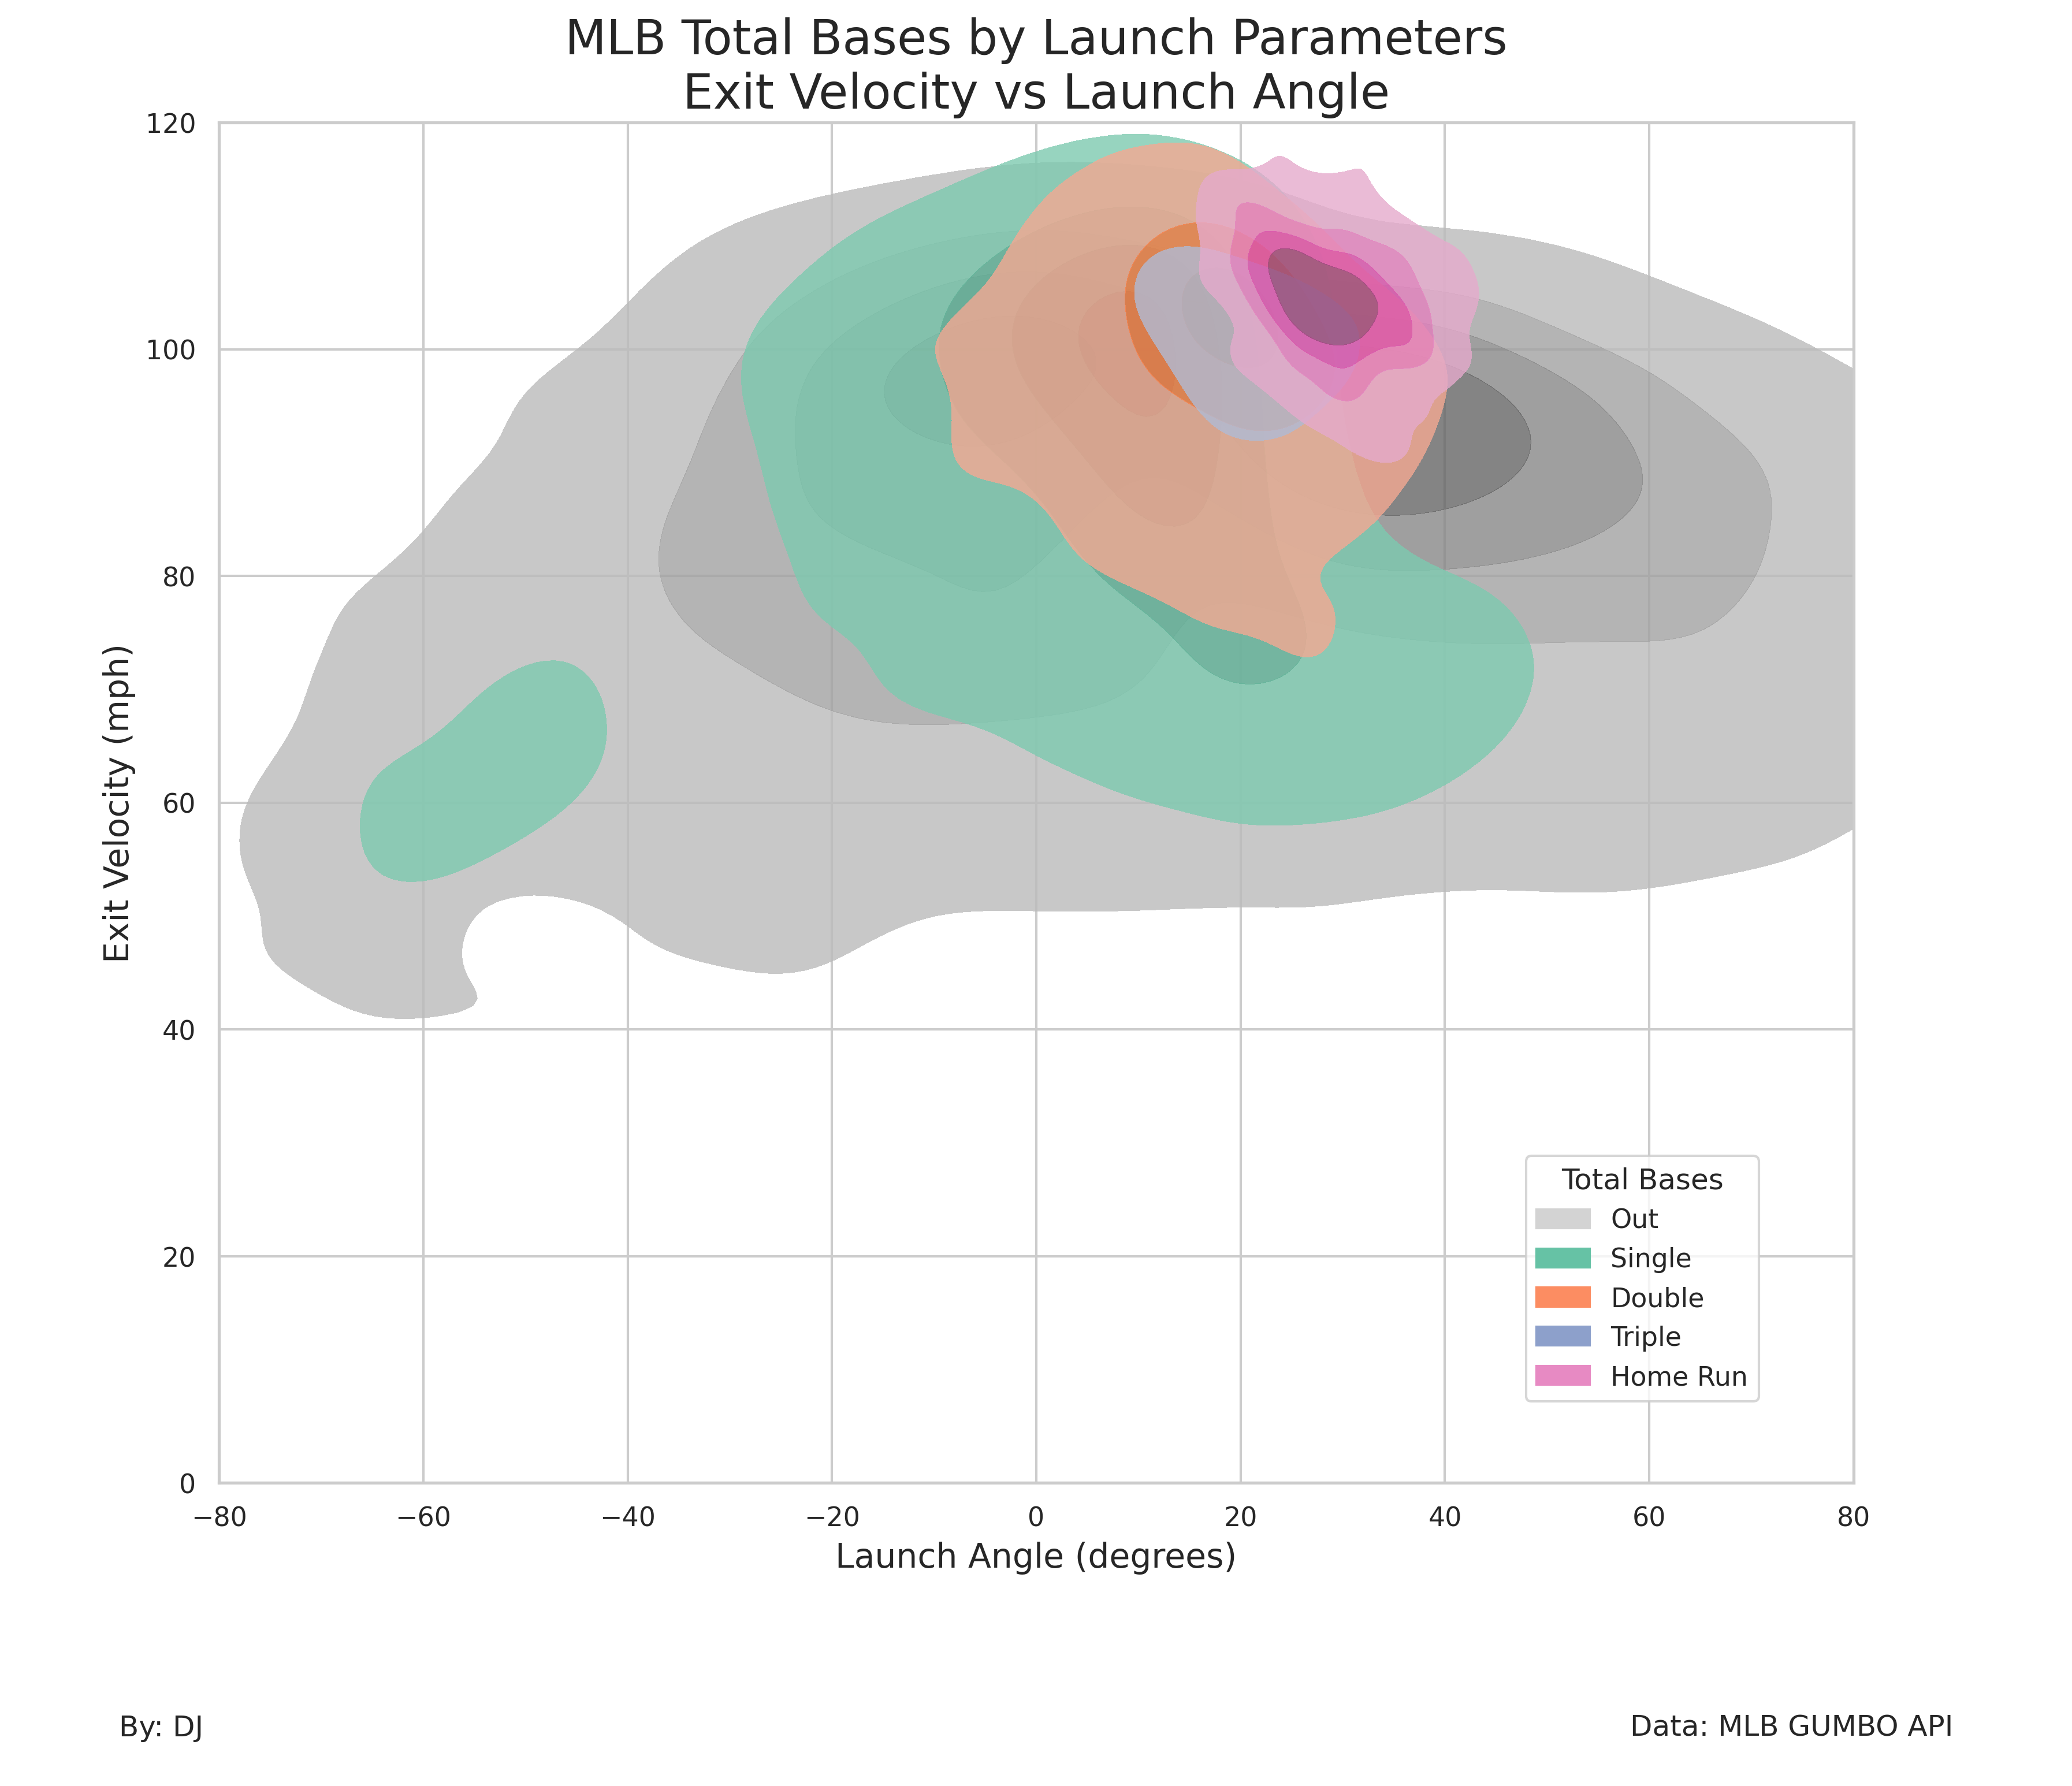

In [ ]:
# Prepare the data
df_bip = df_bip_train

# Sample a portion for faster visualization if the dataset is large
# Adjust the sample size based on your dataset
sample_size = min(10000, len(df_bip))
df_bip_sample = df_bip.sample(sample_size, random_state=42)

# Define a color palette for total bases
colour_palette = ['#D3D3D3', '#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

# Create the visualization
sns.set_theme(style="whitegrid", palette=None)
fig = plt.figure(figsize=(12, 10), dpi=300)

# Create a grid of subplots to maintain layout
gs = GridSpec(2, 3, height_ratios=[10, 1], width_ratios=[0.5, 10, 0.5])

# Add main subplot and footer subplot
ax = fig.add_subplot(gs[0, 1])
axfooter1 = fig.add_subplot(gs[-1, :])

# Define a custom palette for Total Base outcomes in KDE plot
custom_palette = {
    0: colour_palette[0],  # Out
    1: colour_palette[1],  # Single
    2: colour_palette[2],  # Double
    3: colour_palette[3],  # Triple
    4: colour_palette[4]   # Home Run
}

# Generate KDE plot
sns.kdeplot(
    data=df_bip_sample,
    x='launch_angle',
    y='launch_speed',
    hue='tb',
    ax=ax,
    palette=custom_palette,
    fill=True,
    alpha=0.8,
    levels=5
)

# Adjust legend and legend title
legend = ax.get_legend()
legend.set_title('Total Bases')
legend.set_bbox_to_anchor([0.75, 0.1, 0.2, 0.15])

# Map numeric values to outcome names in legend
new_labels = ['Out', 'Single', 'Double', 'Triple', 'Home Run']
for i, text in enumerate(legend.get_texts()):
    if i < len(new_labels):
        text.set_text(new_labels[i])

# Add title to plot
ax.set_title('MLB Total Bases by Launch Parameters\nExit Velocity vs Launch Angle', fontsize=20)

# Add axis labels to plot
ax.set_xlabel('Launch Angle (degrees)', fontsize=14)
ax.set_ylabel('Exit Velocity (mph)', fontsize=14)

# Adjust x and y-axis bounds
ax.set_ylim(0, 120)
ax.set_xlim(-80, 80)

# Add footer text
axfooter1.text(.05, 0.2, "By: DJ", ha='left', va='bottom', fontsize=12)
axfooter1.text(0.95, 0.2, "Data: MLB GUMBO API", ha='right', va='bottom', fontsize=12)
axfooter1.axis('off')

# Adjusting subplot to center it within the figure
fig.subplots_adjust(left=0.01, right=0.99, top=0.975, bottom=0.025)

plt.show()

SPLIT DATASET 2021, 2022, 2023 as training and 2024 as the test set

In [ ]:
# Extract features and target
X_train = df_bip_train[['launch_speed', 'launch_angle']]
y_train = df_bip_train['tb']

X_test = df_bip_2024[['launch_speed', 'launch_angle']]
y_test = df_bip_2024['tb']


In [ ]:
# Standardize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train the K-NN model with the optimal K
knn_model = KNeighborsClassifier(n_neighbors=100)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=100)

In [ ]:
# Make predictions on the test set
y_pred = knn_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# Display confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Test Accuracy: 0.7745

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87     83824
           1       0.64      0.53      0.58     25770
           2       0.44      0.14      0.21      7747
           3       1.00      0.00      0.00       692
           4       0.70      0.68      0.69      5438

    accuracy                           0.77    123471
   macro avg       0.72      0.45      0.47    123471
weighted avg       0.75      0.77      0.75    123471


Confusion Matrix:
[[77114  4976   794     0   940]
 [11717 13754   265     0    34]
 [ 3756  2410  1090     0   491]
 [  343   186    70     0    93]
 [ 1495     1   271     0  3671]]


In [ ]:
# Assuming knn_model.predict_proba(X_test_scaled) is stored in a variable called 'probabilities'
probabilities = knn_model.predict_proba(X_test_scaled)

# Create a DataFrame from the probabilities
probability_df = pd.DataFrame(probabilities, columns=[f'Probability_Class_{i}' for i in range(probabilities.shape[1])])

print(probability_df.head())


   Probability_Class_0  Probability_Class_1  Probability_Class_2  \
0                 0.99                 0.00                 0.01   
1                 0.53                 0.45                 0.02   
2                 0.46                 0.05                 0.41   
3                 0.93                 0.07                 0.00   
4                 0.42                 0.05                 0.32   

   Probability_Class_3  Probability_Class_4  
0                 0.00                 0.00  
1                 0.00                 0.00  
2                 0.00                 0.08  
3                 0.00                 0.00  
4                 0.02                 0.19  


In [ ]:
probability_df.index = df_bip_2024.index

In [ ]:
probability_df.head()

,Probability_Class_0,Probability_Class_1,Probability_Class_2,Probability_Class_3,Probability_Class_4
549136,0.99,0.00,0.01,0.00,0.00
549137,0.53,0.45,0.02,0.00,0.00
549138,0.46,0.05,0.41,0.00,0.08
549142,0.93,0.07,0.00,0.00,0.00
549143,0.42,0.05,0.32,0.02,0.19


In [ ]:
# Concatenate probability_df and df_bip_2024
df_bip_2024 = pd.concat([df_bip_2024, probability_df], axis=1)

In [ ]:
# prompt: create a new column woba_pred that can be made by multiplying probability class 0 by 0, class 1: 0.882, class 2:1.254, class 3:1.590, class 4: 2.050 then summing the result of each of the classes into one column woba_pred

# Define wOBA values for each class
woba_values = {0: 0, 1: 0.882, 2: 1.254, 3: 1.590, 4: 2.050}

# Calculate woba_pred
df_bip_2024['woba_pred'] = 0  # Initialize the column
for i in range(5):
    df_bip_2024['woba_pred'] += df_bip_2024[f'Probability_Class_{i}'] * woba_values[i]


In [ ]:
## Since did not alter the indices, we can assign the predicted xwOBACON to the 2024 dataset
df_2024['woba_pred'] = df_bip_2024['woba_pred']

## Assign a value of 0.689 to every walk in the dataset
df_2024.loc[df_2024['event_type'].isin(['walk']),'woba_pred'] = 0.689

## Assign a value of 0.720 to every hit by pitch in the dataset
df_2024.loc[df_2024['event_type'].isin(['hit_by_pitch']),'woba_pred'] = 0.720

## Assign a value of 0 to every Strikeout in the dataset
df_2024.loc[df_2024['event_type'].isin(['strikeout','strikeout_double_play']),'woba_pred'] = 0

## Create a dataframe which is just wOBA events
df_2024_woba = df_2024.dropna(subset=['woba_pred'])

<ipython-input-23-ee009f64214e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['woba_pred'] = df_bip_2024['woba_pred']


In [ ]:
df_2024.head()

,game_pk,ab_index,play_index,inning,half_inning,is_complete,is_scoring_play,has_review,has_out,start_time,end_time,batter_id,batter_name,pitcher_id,pitcher_name,bat_side,pitch_hand,event,event_type,description,rbi,away_score,home_score,final_balls,final_strikes,final_outs,num_pitches,pitch_types,runner_on_1b,runner_on_2b,runner_on_3b,runs_scored,outs_on_play,launch_speed,launch_angle,total_distance,trajectory,hardness,location,hit_coord_x,hit_coord_y,season,bip,tb,woba,woba_pred
549136,745039,0,0,1,top,True,False,False,True,2024-03-28T23:40:56.507Z,2024-03-28T23:41:07.463Z,664023,Ian Happ,543135,Nathan Eovaldi,L,R,Flyout,field_out,Ian Happ flies out to left fielder Evan Carter.,0,0,0,0.0,0.0,0.0,1,{'FF': 1},False,False,False,0,1,87.3,56.0,226.0,fly_ball,medium,7,91.86,107.11,2024,1.0,0,0.0,0.01254
549137,745039,1,1,1,top,True,False,False,True,2024-03-28T23:41:16.671Z,2024-03-28T23:42:17.392Z,673548,Seiya Suzuki,543135,Nathan Eovaldi,R,R,Groundout,field_out,"Seiya Suzuki grounds out, pitcher Nathan Eoval...",0,0,0,1.0,1.0,1.0,3,"{'FF': 2, 'CU': 1}",False,False,False,0,1,103.0,-3.0,34.0,ground_ball,medium,1,126.35,167.94,2024,1.0,0,0.0,0.42198
549138,745039,2,2,1,top,True,False,False,True,2024-03-28T23:42:21.429Z,2024-03-28T23:45:00.001Z,641355,Cody Bellinger,543135,Nathan Eovaldi,L,R,Lineout,field_out,Cody Bellinger lines out sharply to right fiel...,0,0,0,2.0,2.0,2.0,5,"{'CU': 1, 'FF': 2, 'FS': 2}",False,False,False,0,1,102.4,21.0,362.0,line_drive,hard,9,186.22,65.74,2024,1.0,0,0.0,0.72224
549139,745039,3,3,1,bottom,True,False,False,True,2024-03-28T23:45:46.399Z,2024-03-28T23:48:44.870Z,543760,Marcus Semien,657006,Justin Steele,R,L,Strikeout,strikeout,Marcus Semien strikes out swinging.,0,0,0,3.0,3.0,0.0,6,"{'FF': 4, 'SL': 2}",False,False,False,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,0,0.0,0.00000
549140,745039,4,4,1,bottom,True,False,False,True,2024-03-28T23:48:46.867Z,2024-03-28T23:50:02.707Z,608369,Corey Seager,657006,Justin Steele,L,L,Strikeout,strikeout,Corey Seager strikes out swinging.,0,0,0,1.0,3.0,1.0,4,"{'FF': 3, 'SL': 1}",False,False,False,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,0,0.0,0.00000


In [ ]:
## Groupby Batter ID and Name to calculate wOBA and xwOBA for all players during 2024 MLB Season
df_2024_output = df_2024_woba.groupby(['batter_id','batter_name']).agg(
    woba_pa = ('woba_pred','count'),
    woba = ('woba','mean'),
    xwoba = ('woba_pred','mean'))

## Only include batters with at least 100 wOBA PA
df_2024_output = df_2024_output[df_2024_output['woba_pa'] > 100]

## Display the top 20
df_2024_output[df_2024_output['woba_pa'] > 350].sort_values(by='xwoba',ascending=False).head(20)

,,woba_pa,woba,xwoba
batter_id,batter_name,,,
592450,Aaron Judge,682,0.476453,0.482400
665742,Juan Soto,710,0.421193,0.467515
660271,Shohei Ohtani,717,0.431181,0.449806
670541,Yordan Alvarez,619,0.401617,0.418974
665489,Vladimir Guerrero Jr.,683,0.399083,0.411483
542303,Marcell Ozuna,682,0.393686,0.405446
677951,Bobby Witt Jr.,696,0.410322,0.403438
608369,Corey Seager,515,0.362808,0.396466
606466,Ketel Marte,575,0.391715,0.392555


In [ ]:
# prompt: open csv file from my computer

from google.colab import files
uploaded = files.upload()


Saving expected_stats.csv to expected_stats.csv


In [ ]:
expected_stats_df = pd.read_csv('expected_stats.csv')

In [ ]:
## merge our model xwOBA with MLB xwOBA. Only include qualified batters
df_2024_output_merge = df_2024_output.reset_index().merge(right=expected_stats_df,
                                                          left_on='batter_id',
                                                          right_on='player_id',
                                                          suffixes = ['','_MLB']).set_index(['batter_id','batter_name'])

Text(0.21, 0.475, '$R^{2}$ = 0.98')

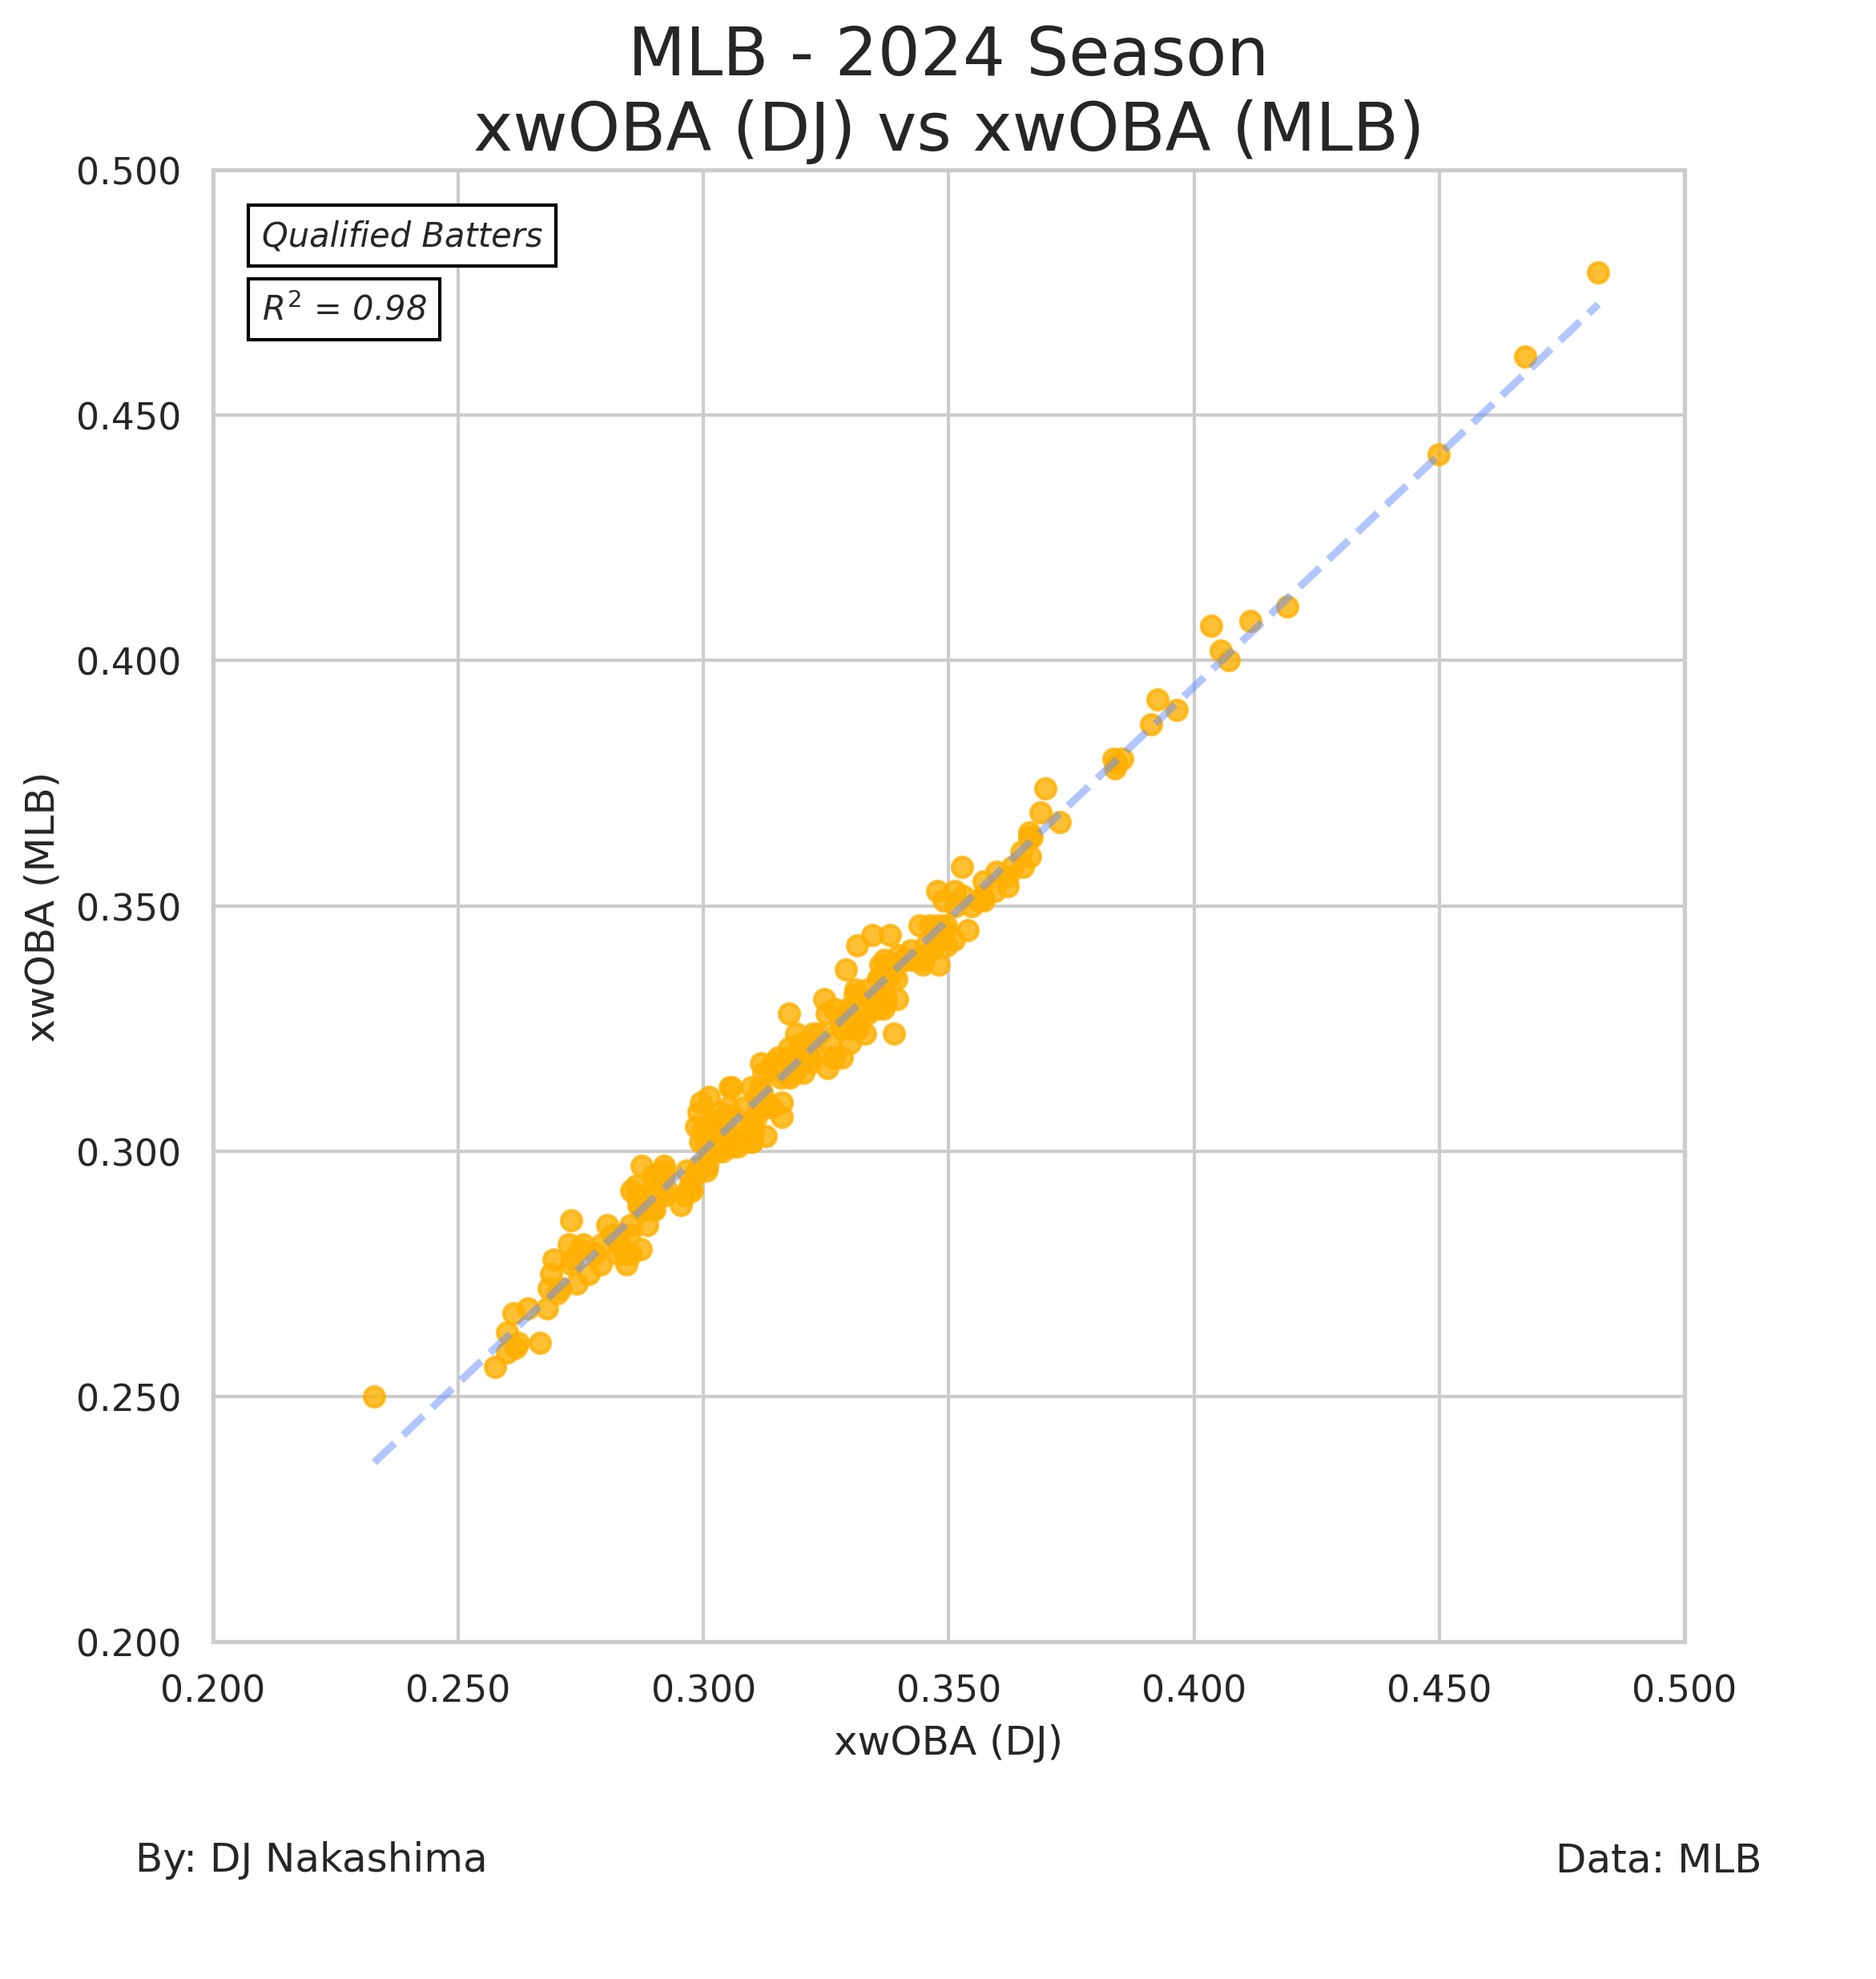

In [ ]:
## Initialize Plot
sns.set_theme(style="whitegrid", palette="pastel")
fig = plt.figure(figsize=(8,8),dpi=300)

## Create a grid of subplots to maintain layout
gs = GridSpec(2, 3, height_ratios=[12,1], width_ratios=[0.5,12,0.5])

## Add main subplot and footer subplot
ax = fig.add_subplot(gs[0, 1])
axfooter1 = fig.add_subplot(gs[-1, :])

## Plot Regression plot
sns.regplot(data=df_2024_output_merge,
             x='xwoba',
             y='est_woba',
             #color=colour_palette[0],
            scatter_kws={"color": colour_palette[0]},  # Set color of scatter points
            line_kws={"color": colour_palette[1],"linestyle":'dashed',"alpha":0.5},ci=None,ax=ax)

## Make axis square
ax.axis('square')

## Define x and y bounds
ax.set_xlim(0.2,0.5)
ax.set_ylim(0.2,0.5)

## Import function to format x and y ticks
from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))

## Add Title
ax.set_title('MLB - 2024 Season\nxwOBA (DJ) vs xwOBA (MLB)',fontsize=20)

## Set Labels
ax.set_xlabel('xwOBA (DJ)')
ax.set_ylabel('xwOBA (MLB)')

## Add fotter text
axfooter1.text(.05, 0.6, "By: DJ Nakashima",ha='left', va='bottom',fontsize=12)
axfooter1.text(0.95, 0.6, "Data: MLB",ha='right', va='bottom',fontsize=12)
axfooter1.axis('off')

## Adjusting subplot to center it within the figure
fig.subplots_adjust(left=0.03, right=0.97, top=0.97, bottom=0.03)

## Add text with information regarding data points shown and correlation
ax.text(x=0.21,
        y=0.49,
        s=f'Qualified Batters',
        fontsize='10',
        fontstyle='oblique',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black'))

ax.text(x=0.21,
        y=0.475,
        s=r"$R^{2}$" + f" = {r2_score(df_2024_output_merge['xwoba'],df_2024_output_merge['est_woba']):.2f}",
        fontsize='10',
        fontstyle='oblique',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black'))

**Adding Sprint Speed**

Based on the K-nn model we get a 77.48% accuracy. Which does a good job of capturing the relationship between batted balls and their expected outcomes. However, to further improve this model and to get real world results sprint speed which accounts for the singles on infield hits need to be accounted for.

In [ ]:
!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 856.7/856.7 kB 54.1 MB/s eta 0:00:00


In [ ]:
from pybaseball import statcast_sprint_speed

# All players with at least 1 opportunities from 2021-2024
sprint_speed_2021 = statcast_sprint_speed(2021, 1)
sprint_speed_2022 = statcast_sprint_speed(2022, 1)
sprint_speed_2023 = statcast_sprint_speed(2023, 1)
sprint_speed_2024 = statcast_sprint_speed(2024, 1)

In [ ]:
sprint_speed_2021['season'] = 2021
sprint_speed_2022['season'] = 2022
sprint_speed_2023['season'] = 2023
sprint_speed_2024['season'] = 2024

# Combine the DataFrames
sprint_speed = pd.concat([sprint_speed_2021, sprint_speed_2022, sprint_speed_2023, sprint_speed_2024], ignore_index=True)


In [ ]:
sprint_speed.head()

,"last_name, first_name",player_id,team_id,team,position,age,competitive_runs,bolts,hp_to_1b,sprint_speed,season
0,"Turner, Trea",607208,119,LAD,SS,28,277,147.0,4.13,30.6,2021
1,"Locastro, Tim",641796,147,NYY,CF,28,48,36.0,4.07,30.6,2021
2,"Hill, Derek",656537,116,DET,CF,25,45,36.0,4.19,30.4,2021
3,"McCarthy, Jake",664983,109,AZ,CF,23,28,19.0,NaN,30.4,2021
4,"White, Eli",642201,140,TEX,LF,27,69,37.0,4.16,30.4,2021


In [ ]:
# Merge sprint_speed with df
df = pd.merge(df, sprint_speed[['player_id', 'sprint_speed', 'season']],
              left_on=['batter_id', 'season'],
              right_on=['player_id', 'season'],
              how='left')


In [ ]:
## Filter out all non-batted ball events for training
df_bip = df[~df['bip'].isnull()].dropna(subset=['launch_speed','launch_angle','bip'])

## Train on 2021-23 Data and keep 2024 Data for analysis
df_bip_train = df_bip[~(df_bip['season'] == 2024)]
df_bip_2024 = df_bip[df_bip['season'] == 2024]

## Filter out 2024 data for use later
df_2024 = df[df['season'] == 2024]

In [ ]:
features = ['launch_speed', 'launch_angle', 'sprint_speed']
X_train = df_bip_train[features]
y_train = df_bip_train['tb']

X_test = df_bip_2024[features]
y_test = df_bip_2024['tb']

In [ ]:
import lightgbm as lgb

In [ ]:
# --- Initialize LightGBM Classifier ---
# Key parameters for multi-class classification:
# objective='multiclass': Specifies the task type.
# metric='multi_logloss': Evaluation metric during training.
# num_class: MUST be specified for multiclass objective. Determined above.
# random_state: For reproducibility.

lgbm_clf = lgb.LGBMClassifier(
    objective='multiclass',
    metric='multi_logloss',
    num_class=5,   # Using value calculated above
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)
# ----------------------------------------

# --- Train the Model ---
print("\nTraining LightGBM model...")
# Fit directly using the raw y_train (assuming it's 0-indexed integers)
lgbm_clf.fit(X_train, y_train)
print("Training complete.")
# ----------------------------------------

# --- Make Predictions ---
# Predict probabilities for each class (0, 1, 2, 3, 4)
y_pred_proba = lgbm_clf.predict_proba(X_test)

# Predict the most likely class label (will be 0, 1, 2, 3, or 4 directly)
y_pred_class = lgbm_clf.predict(X_test)
# No inverse_transform needed as we are predicting the raw class indices
# ----------------------------------------

# --- Evaluate the Model ---
print("\n--- Model Evaluation ---")

# 1. Accuracy
# Compare raw y_test with the predicted class indices
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy:.4f}")

# 2. Log Loss
# Compare raw y_test with the predicted probabilities
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss:.4f}")

# 3. Classification Report
# Uses raw y_test and predicted class indices.
# Dynamically get labels expected in the report from unique values.
report_labels = sorted(df_bip_train['tb'].unique()) # Use unique values from training for consistency
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, labels=report_labels, zero_division=0))

# 4. Feature Importances
print("\nFeature Importances:")
feature_imp = pd.DataFrame(sorted(zip(lgbm_clf.feature_importances_, features)), columns=['Value','Feature'])
print(feature_imp)
# ----------------------------------------

# --- Example Output ---
# Show probabilities for the first few test samples
print("\nPredicted Probabilities (first 5 samples):")
# Create a DataFrame for better visualization - use the sorted unique classes as column names
proba_df = pd.DataFrame(y_pred_proba, columns=[f'P(TB={cls})' for cls in report_labels])
proba_df.head()


Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 494
[LightGBM] [Info] Number of data points in the train set: 368688, number of used features: 3
[LightGBM] [Info] Start training from score -0.392265
[LightGBM] [Info] Start training from score -1.571093
[LightGBM] [Info] Start training from score -2.732064
[LightGBM] [Info] Start training from score -5.206358
[LightGBM] [Info] Start training from score -3.077149
Training complete.

--- Model Evaluation ---
Accuracy: 0.7750
Log Loss: 0.5634

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87     83824
           1       0.64      0.54      0.59     25770
           2       0.44      0.16      0.23      7747
           3       0.11      0

,P(TB=0),P(TB=1),P(TB=2),P(TB=3),P(TB=4)
0,0.987430,0.005658,0.006893,0.000010,0.000009
1,0.617467,0.352342,0.027291,0.002882,0.000017
2,0.425510,0.029347,0.445612,0.045575,0.053956
3,0.949299,0.047590,0.003077,0.000025,0.000009
4,0.407025,0.020538,0.355200,0.028171,0.189067


In [ ]:
proba_df.index = df_bip_2024.index

In [ ]:
# Rename the columns of proba_df
proba_df = proba_df.rename(columns={
    'P(TB=0)': 'Probability_Class_0',
    'P(TB=1)': 'Probability_Class_1',
    'P(TB=2)': 'Probability_Class_2',
    'P(TB=3)': 'Probability_Class_3',
    'P(TB=4)': 'Probability_Class_4'
})


In [ ]:
# Concatenate probability_df and df_bip_2024
df_bip_2024 = pd.concat([df_bip_2024, proba_df], axis=1)

In [ ]:
df_bip_2024.head()

,game_pk,ab_index,play_index,inning,half_inning,is_complete,is_scoring_play,has_review,has_out,start_time,end_time,batter_id,batter_name,pitcher_id,pitcher_name,bat_side,pitch_hand,event,event_type,description,rbi,away_score,home_score,final_balls,final_strikes,final_outs,num_pitches,pitch_types,runner_on_1b,runner_on_2b,runner_on_3b,runs_scored,outs_on_play,launch_speed,launch_angle,total_distance,trajectory,hardness,location,hit_coord_x,hit_coord_y,season,bip,tb,woba,player_id,sprint_speed,Probability_Class_0,Probability_Class_1,Probability_Class_2,Probability_Class_3,Probability_Class_4
549136,745039,0,0,1,top,True,False,False,True,2024-03-28T23:40:56.507Z,2024-03-28T23:41:07.463Z,664023,Ian Happ,543135,Nathan Eovaldi,L,R,Flyout,field_out,Ian Happ flies out to left fielder Evan Carter.,0,0,0,0.0,0.0,0.0,1,{'FF': 1},False,False,False,0,1,87.3,56.0,226.0,fly_ball,medium,7,91.86,107.11,2024,1.0,0,0.00,664023.0,27.9,0.987430,0.005658,0.006893,0.000010,0.000009
549137,745039,1,1,1,top,True,False,False,True,2024-03-28T23:41:16.671Z,2024-03-28T23:42:17.392Z,673548,Seiya Suzuki,543135,Nathan Eovaldi,R,R,Groundout,field_out,"Seiya Suzuki grounds out, pitcher Nathan Eoval...",0,0,0,1.0,1.0,1.0,3,"{'FF': 2, 'CU': 1}",False,False,False,0,1,103.0,-3.0,34.0,ground_ball,medium,1,126.35,167.94,2024,1.0,0,0.00,673548.0,28.3,0.617467,0.352342,0.027291,0.002882,0.000017
549138,745039,2,2,1,top,True,False,False,True,2024-03-28T23:42:21.429Z,2024-03-28T23:45:00.001Z,641355,Cody Bellinger,543135,Nathan Eovaldi,L,R,Lineout,field_out,Cody Bellinger lines out sharply to right fiel...,0,0,0,2.0,2.0,2.0,5,"{'CU': 1, 'FF': 2, 'FS': 2}",False,False,False,0,1,102.4,21.0,362.0,line_drive,hard,9,186.22,65.74,2024,1.0,0,0.00,641355.0,28.4,0.425510,0.029347,0.445612,0.045575,0.053956
549142,745039,6,6,1,bottom,True,False,False,True,2024-03-28T23:53:11.662Z,2024-03-28T23:55:16.584Z,666969,Adolis García,657006,Justin Steele,R,L,Groundout,field_out,"Adolis García grounds out, third baseman Nick ...",0,0,0,2.0,2.0,2.0,5,"{'FF': 4, 'SL': 1}",False,False,False,0,1,74.8,-22.0,6.0,ground_ball,medium,5,110.04,177.98,2024,1.0,0,0.00,666969.0,26.8,0.949299,0.047590,0.003077,0.000025,0.000009
549143,745039,7,7,2,top,True,False,False,False,2024-03-28T23:56:03.709Z,2024-03-28T23:58:05.274Z,666624,Christopher Morel,543135,Nathan Eovaldi,R,R,Triple,triple,Christopher Morel triples (1) on a fly ball to...,0,0,0,0.0,0.0,0.0,1,{'CU': 1},False,False,False,0,0,101.6,23.0,374.0,fly_ball,medium,7,55.52,83.49,2024,1.0,3,1.59,666624.0,27.3,0.407025,0.020538,0.355200,0.028171,0.189067


In [ ]:
# Define wOBA values for each class
woba_values = {0: 0, 1: 0.882, 2: 1.254, 3: 1.590, 4: 2.050}

# Calculate woba_pred_speed
df_bip_2024['woba_pred'] = 0  # Initialize the column
for i in range(5):
    df_bip_2024['woba_pred'] += df_bip_2024[f'Probability_Class_{i}'] * woba_values[i]


In [ ]:
## Since did not alter the indices, we can assign the predicted xwOBACON to the 2024 dataset
df_2024['woba_pred'] = df_bip_2024['woba_pred']

## Assign a value of 0.689 to every walk in the dataset
df_2024.loc[df_2024['event_type'].isin(['walk']),'woba_pred'] = 0.689

## Assign a value of 0.720 to every hit by pitch in the dataset
df_2024.loc[df_2024['event_type'].isin(['hit_by_pitch']),'woba_pred'] = 0.720

## Assign a value of 0 to every Strikeout in the dataset
df_2024.loc[df_2024['event_type'].isin(['strikeout','strikeout_double_play']),'woba_pred'] = 0

## Create a dataframe which is just wOBA events
df_2024_woba = df_2024.dropna(subset=['woba_pred'])

<ipython-input-111-ee009f64214e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['woba_pred'] = df_bip_2024['woba_pred']


In [ ]:
## Groupby Batter ID and Name to calculate wOBA and xwOBA for all players during 2023 MLB Season
df_2024_output = df_2024_woba.groupby(['batter_id','batter_name']).agg(
    woba_pa = ('woba_pred','count'),
    woba = ('woba','mean'),
    xwoba_speed = ('woba_pred','mean'))

## Only include batters with at least 100 wOBA PA
df_2024_output = df_2024_output[df_2024_output['woba_pa'] > 100]

## Display the top 20
df_2024_output[df_2024_output['woba_pa'] > 350].sort_values(by='xwoba_speed',ascending=False).head(20)

,,woba_pa,woba,xwoba_speed
batter_id,batter_name,,,
592450,Aaron Judge,682,0.476453,0.483274
665742,Juan Soto,710,0.421193,0.464164
660271,Shohei Ohtani,717,0.431181,0.453142
677951,Bobby Witt Jr.,696,0.410322,0.416558
670541,Yordan Alvarez,619,0.401617,0.414963
665489,Vladimir Guerrero Jr.,683,0.399083,0.408591
542303,Marcell Ozuna,682,0.393686,0.397436
665487,Fernando Tatis Jr.,436,0.358427,0.395976
606466,Ketel Marte,575,0.391715,0.391345


Text(0.21, 0.475, '$R^{2}$ = 0.98')

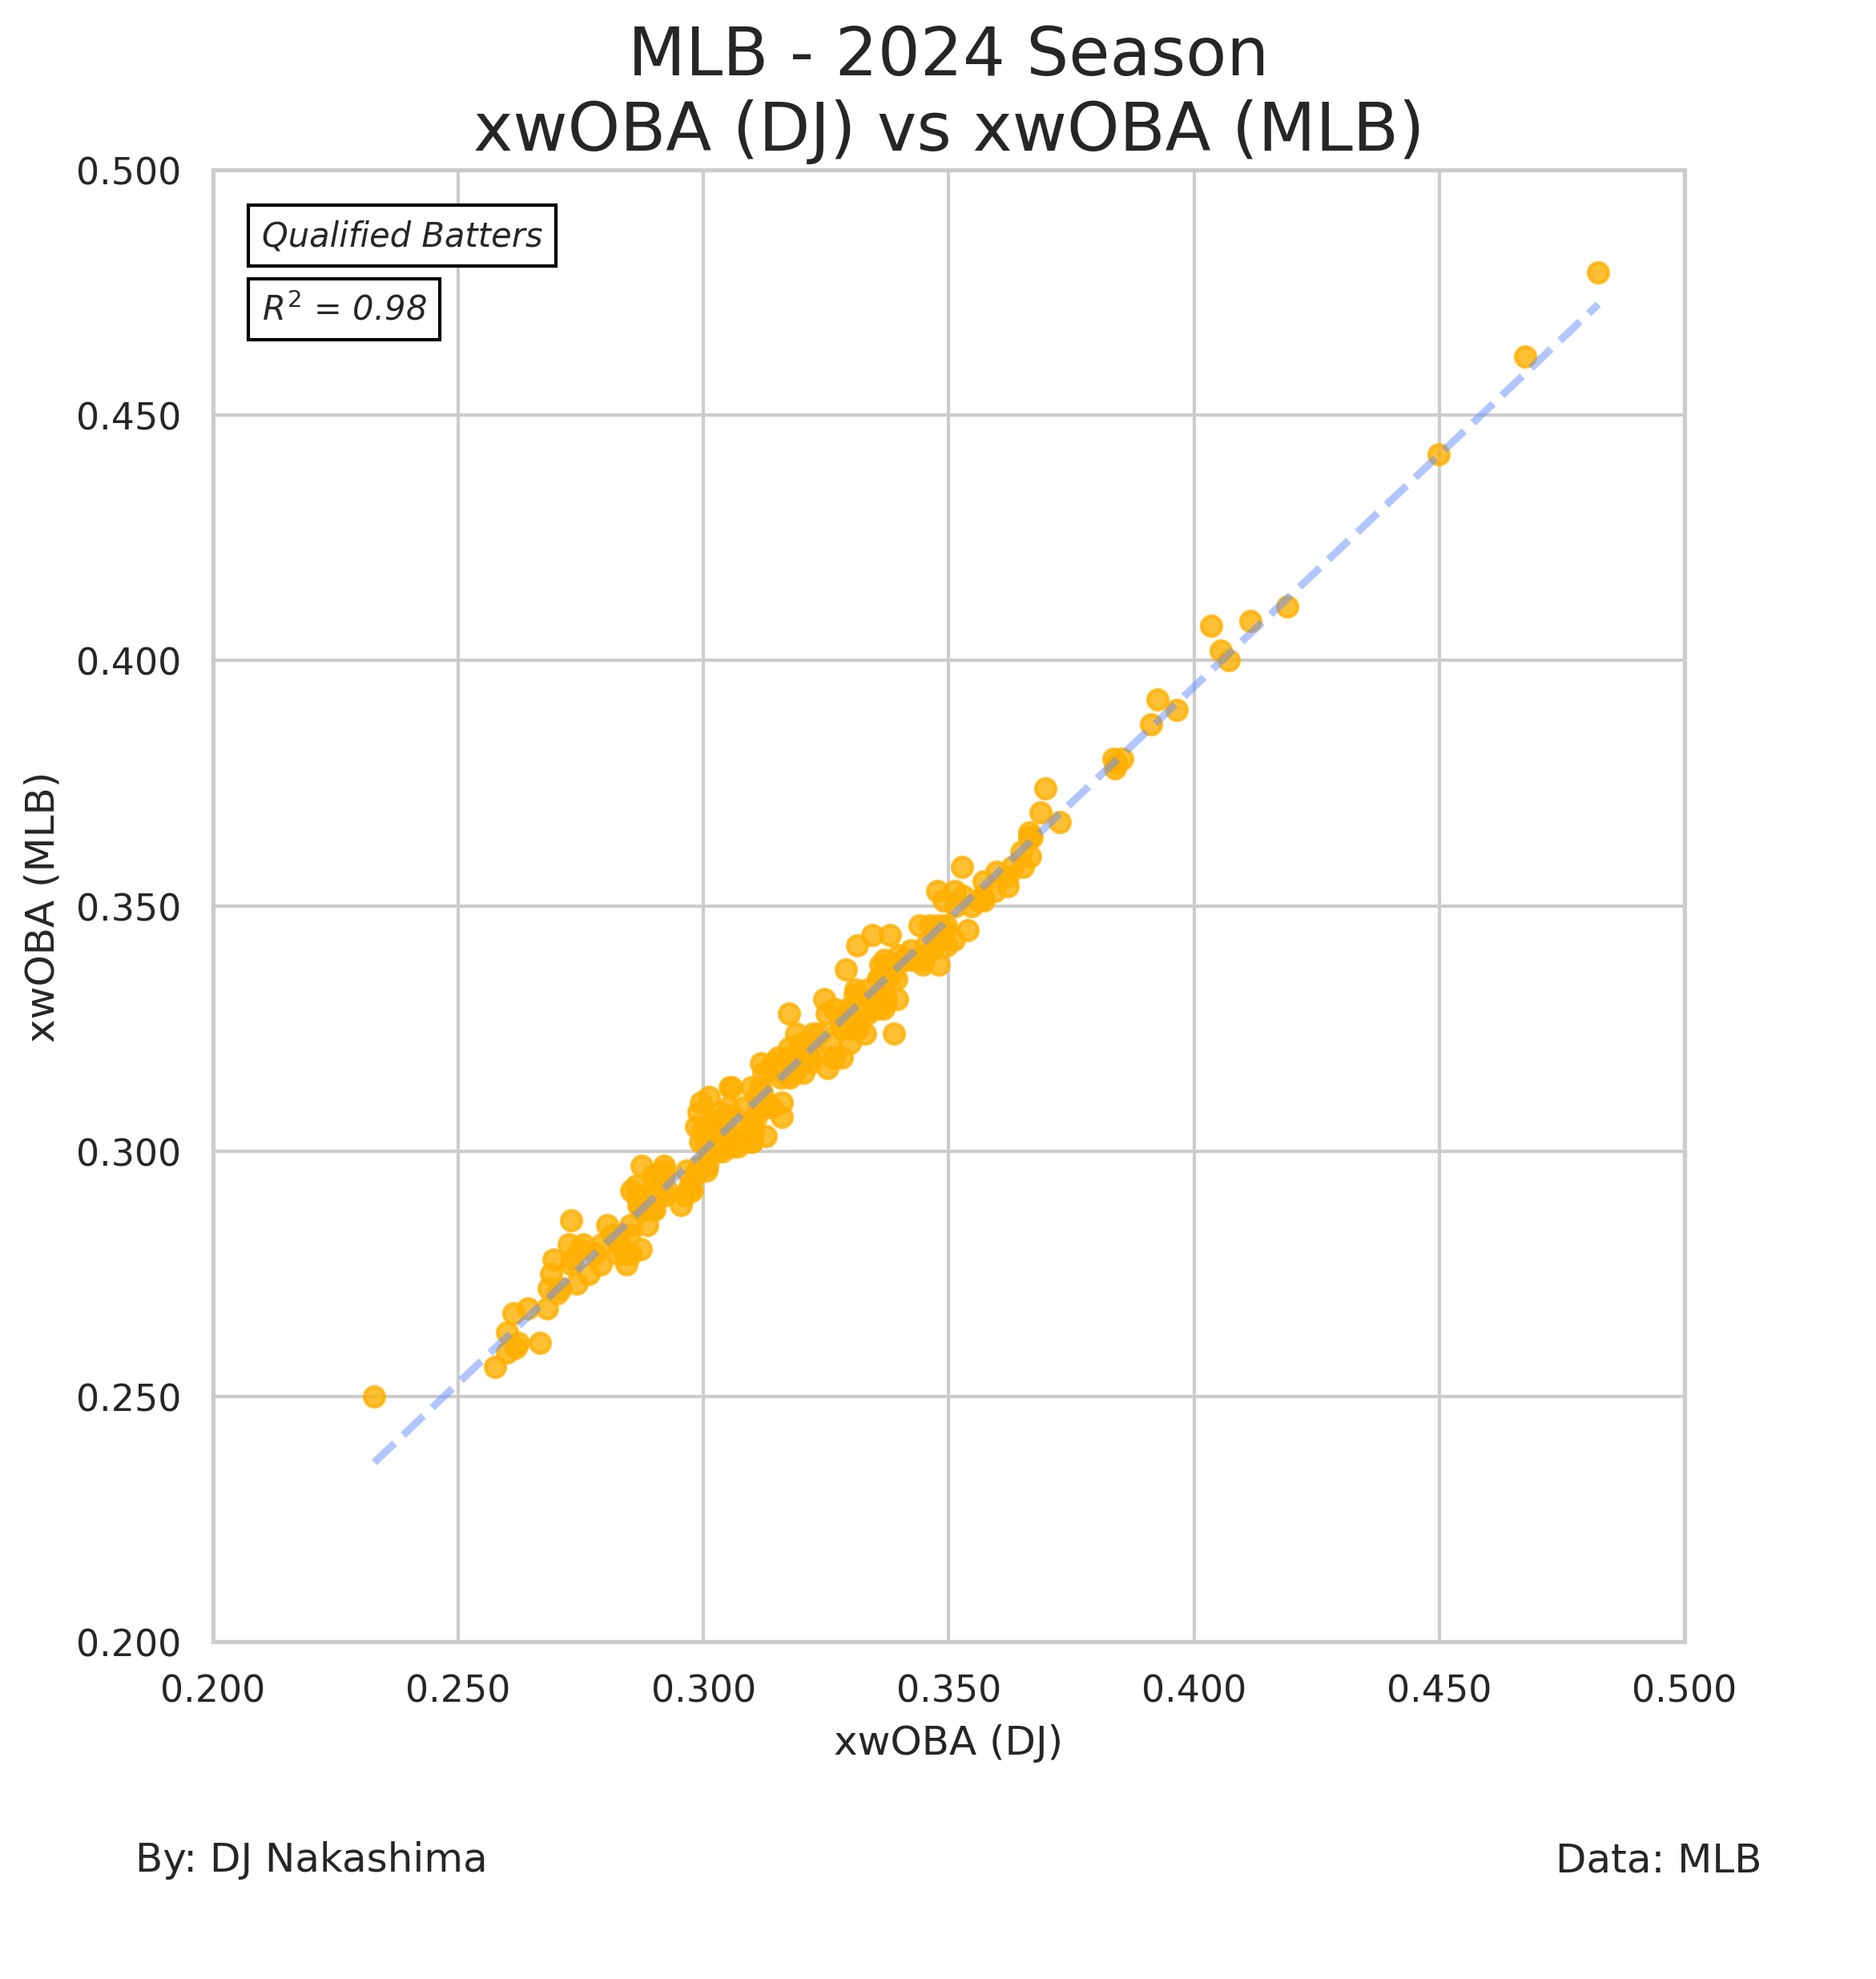

In [ ]:
## Initialize Plot
sns.set_theme(style="whitegrid", palette="pastel")
fig = plt.figure(figsize=(8,8),dpi=300)

## Create a grid of subplots to maintain layout
gs = GridSpec(2, 3, height_ratios=[12,1], width_ratios=[0.5,12,0.5])

## Add main subplot and footer subplot
ax = fig.add_subplot(gs[0, 1])
axfooter1 = fig.add_subplot(gs[-1, :])

## Plot Regression plot
sns.regplot(data=df_2024_output_merge,
             x='xwoba',
             y='est_woba',
             #color=colour_palette[0],
            scatter_kws={"color": colour_palette[0]},  # Set color of scatter points
            line_kws={"color": colour_palette[1],"linestyle":'dashed',"alpha":0.5},ci=None,ax=ax)

## Make axis square
ax.axis('square')

## Define x and y bounds
ax.set_xlim(0.2,0.5)
ax.set_ylim(0.2,0.5)

## Import function to format x and y ticks
from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))

## Add Title
ax.set_title('MLB - 2024 Season\nxwOBA (DJ) vs xwOBA (MLB)',fontsize=20)

## Set Labels
ax.set_xlabel('xwOBA (DJ)')
ax.set_ylabel('xwOBA (MLB)')

## Add fotter text
axfooter1.text(.05, 0.6, "By: DJ Nakashima",ha='left', va='bottom',fontsize=12)
axfooter1.text(0.95, 0.6, "Data: MLB",ha='right', va='bottom',fontsize=12)
axfooter1.axis('off')

## Adjusting subplot to center it within the figure
fig.subplots_adjust(left=0.03, right=0.97, top=0.97, bottom=0.03)

## Add text with information regarding data points shown and correlation
ax.text(x=0.21,
        y=0.49,
        s=f'Qualified Batters',
        fontsize='10',
        fontstyle='oblique',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black'))

ax.text(x=0.21,
        y=0.475,
        s=r"$R^{2}$" + f" = {r2_score(df_2024_output_merge['xwoba'],df_2024_output_merge['est_woba']):.2f}",
        fontsize='10',
        fontstyle='oblique',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black'))